In [2]:
!pip install pandas scikit-learn matplotlib seaborn spacy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.6 MB/s  0:00:07 eta 0:00:01m

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [6]:
import os
print(os.path.exists("/Users/lathifash/Documents/TugasAkhir/code/all_articles.csv"))

True


In [8]:
import os
import pandas as pd

# 1. Cek file exist
csv_path = "/Users/lathifash/Documents/TugasAkhir/code/all_articles.csv"
print(f"File exists: {os.path.exists(csv_path)}")

# 2. Cek bisa dibaca
df_test = pd.read_csv(csv_path)
print(f"Loaded {len(df_test):,} rows")
print(f"Columns: {df_test.columns.tolist()}")

# 3. Cek kolom penting
required_cols = ['text', 'title']
for col in required_cols:
    if col in df_test.columns:
        print(f"✅ Column '{col}' found")
    else:
        print(f"❌ Column '{col}' NOT found")

File exists: True
Loaded 1,000 rows
Columns: ['title', 'text', 'published']
✅ Column 'text' found
✅ Column 'title' found



FASE 1: DATA PREPARATION & UNDERSTANDING - COMPLETE PIPELINE
STEP 1.1: LOADING DATASET

📂 Loading from: /Users/lathifash/Documents/TugasAkhir/code/all_articles.csv
✅ Loaded 1,000 articles

📋 Columns (3):
   • title
   • text
   • published

📊 Data Types:
title        object
text         object
published    object
dtype: object

🔍 Missing Values:
   No missing values!

📰 Sample Articles:

   Article 1:
   Title: Chart Industries Secures Strategic LNG Contracts: Morocco Regasification Units, ...
   Text length: 238 words

   Article 2:
   Title: Apple's New M3 Pro MacBook Pro Gets an Epic $300 Price Drop...
   Text length: 291 words

   Article 3:
   Title: CADCHF: Bullish Reversal Potential - Long Trade Setup...
   Text length: 348 words

STEP 1.2: DATA FILTERING

🔍 Applying research criteria...

   Adding features:
      → Word count...

📏 Calculating word counts...
   Mean: 767 words
   Median: 548 words
   Range: 102-6333 words
      → Domain detection...
      → Event counting...
 

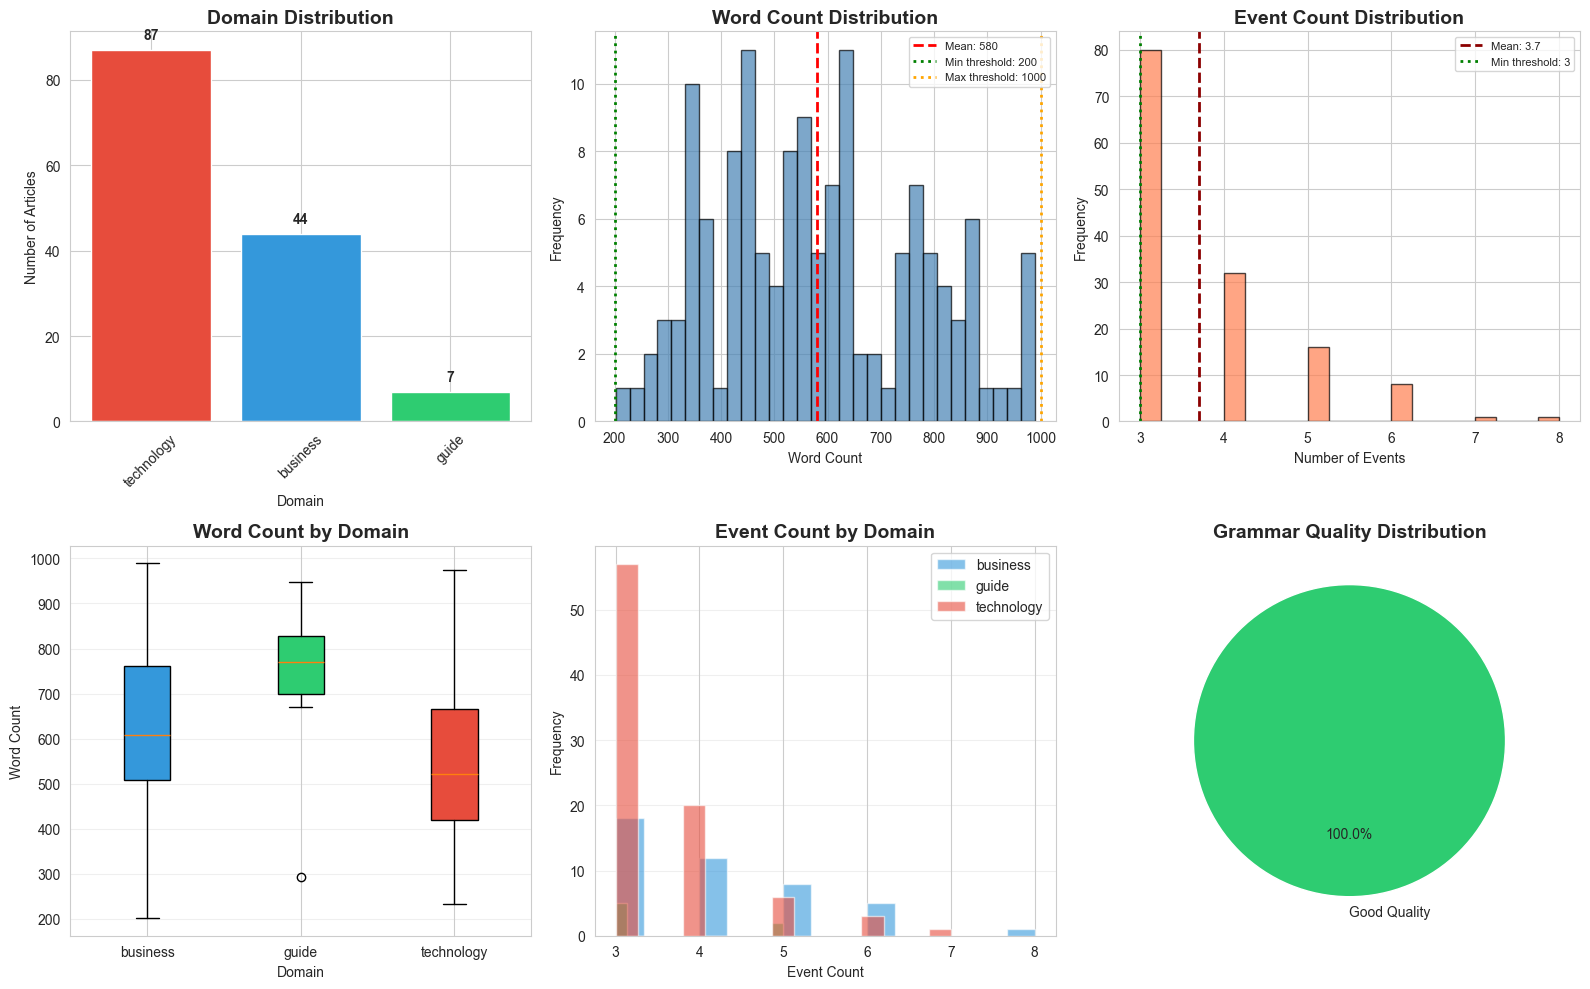


✅ FASE 1 COMPLETED SUCCESSFULLY!

Generated files:
   • filtered_articles.csv
   • train_set.csv
   • val_set.csv
   • test_set.csv
   • phase1_eda_complete.png

📝 Next steps:
   1. Review the filtered dataset
   2. Check visualizations in phase1_eda_complete.png
   3. Document findings in Bab 3.1 of your thesis
   4. Proceed to FASE 2: Rule-Based Pre-Processing


In [11]:
"""
FASE 1: Data Preparation & Understanding - Complete Pipeline
Customized for dataset with columns: title, text, published
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


# ============================================================================
# STEP 1.1: DATASET LOADING & CLEANING
# ============================================================================

class DatasetLoader:
    """Load and inspect dataset from CSV"""

    def __init__(self, csv_path="/Users/lathifash/Documents/TugasAkhir/code/all_articles.csv"):
        self.csv_path = csv_path
        self.df = None

    def load_and_inspect(self):
        """Load CSV and show basic info"""
        print("=" * 70)
        print("STEP 1.1: LOADING DATASET")
        print("=" * 70)

        print(f"\n📂 Loading from: {self.csv_path}")
        self.df = pd.read_csv(self.csv_path)

        print(f"✅ Loaded {len(self.df):,} articles")
        print(f"\n📋 Columns ({len(self.df.columns)}):")
        for col in self.df.columns:
            print(f"   • {col}")

        print(f"\n📊 Data Types:")
        print(self.df.dtypes)

        print(f"\n🔍 Missing Values:")
        missing = self.df.isnull().sum()
        if missing.sum() > 0:
            print(missing[missing > 0])
        else:
            print("   No missing values!")

        # Show sample
        print(f"\n📰 Sample Articles:")
        for idx, row in self.df.head(3).iterrows():
            print(f"\n   Article {idx+1}:")
            print(f"   Title: {row['title'][:80]}...")
            print(f"   Text length: {len(str(row['text']).split())} words")

        return self.df


# ============================================================================
# STEP 1.2: DATA FILTERING
# ============================================================================

class DatasetFilter:
    """Filter articles based on research criteria"""

    def __init__(self, df):
        self.df = df.copy()

    def add_word_count(self):
        """Calculate word count for each article"""
        print("\n📏 Calculating word counts...")

        self.df['word_count'] = self.df['text'].apply(
            lambda x: len(str(x).split()) if pd.notna(x) else 0
        )

        print(f"   Mean: {self.df['word_count'].mean():.0f} words")
        print(f"   Median: {self.df['word_count'].median():.0f} words")
        print(f"   Range: {self.df['word_count'].min()}-{self.df['word_count'].max()} words")

        return self.df

    def detect_domain(self, text):
        """Detect article domain based on text content only"""
        text_lower = str(text).lower() if pd.notna(text) else ''

        # Business keywords
        business_kw = ['company', 'companies', 'market', 'revenue', 'stock', 'ceo',
                      'investment', 'profit', 'business', 'financial', 'enterprise',
                      'economy', 'trade', 'industry', 'sales', 'investor', 'merger',
                      'corporate', 'earnings', 'quarterly', 'shareholders']

        # Technology keywords
        tech_kw = ['technology', 'software', 'ai', 'artificial intelligence', 'app',
                  'digital', 'tech', 'innovation', 'platform', 'system', 'data',
                  'algorithm', 'computer', 'internet', 'cyber', 'cloud', 'startup',
                  'hardware', 'programming', 'developer', 'smartphone', 'devices']

        # Guide/Tutorial keywords
        guide_kw = ['how to', 'step', 'guide', 'tutorial', 'process', 'method',
                   'way to', 'tips', 'instructions', 'procedure', 'follow these',
                   'you can', 'you should', 'make sure', 'here are']

        scores = {
            'business': sum(1 for kw in business_kw if kw in text_lower),
            'technology': sum(1 for kw in tech_kw if kw in text_lower),
            'guide': sum(1 for kw in guide_kw if kw in text_lower)
        }

        domain = max(scores, key=scores.get)
        return domain if scores[domain] > 0 else 'other'

    def count_events(self, text):
        """Count events/actions in article"""
        if pd.isna(text):
            return 0

        text_lower = str(text).lower()

        action_verbs = ['announced', 'launched', 'released', 'introduced', 'developed',
                       'created', 'implemented', 'signed', 'agreed', 'approved',
                       'revealed', 'opened', 'closed', 'started', 'began', 'completed',
                       'said', 'stated', 'reported', 'confirmed', 'published',
                       'unveiled', 'expanded', 'acquired', 'merged', 'appointed']

        temporal_markers = ['then', 'after', 'before', 'later', 'next', 'subsequently',
                          'following', 'previously', 'today', 'yesterday', 'recently',
                          'now', 'soon', 'earlier', 'meanwhile']

        verb_count = sum(1 for verb in action_verbs if f' {verb} ' in text_lower)
        temporal_count = sum(1 for marker in temporal_markers if f' {marker} ' in text_lower)

        return verb_count + (temporal_count // 2)

    def check_grammar_quality(self, text):
        """Basic grammar quality check"""
        if pd.isna(text) or len(str(text).strip()) < 50:
            return False

        sentences = re.split(r'[.!?]+', str(text))
        sentences = [s.strip() for s in sentences if len(s.strip()) > 5]

        if len(sentences) < 3:
            return False

        # Check capitalization
        capital_count = sum(1 for s in sentences if s and s[0].isupper())
        capital_ratio = capital_count / len(sentences) if len(sentences) > 0 else 0

        # Check sentence length
        sentence_lengths = [len(s.split()) for s in sentences]
        avg_length = np.mean(sentence_lengths) if sentence_lengths else 0

        return capital_ratio > 0.5 and 8 <= avg_length <= 60

    def apply_research_criteria(self):
        """Apply all filtering criteria from Bab 3"""
        print("\n🔍 Applying research criteria...")
        print("=" * 70)

        # Remove rows with missing text
        initial_count = len(self.df)
        self.df = self.df.dropna(subset=['text']).copy()
        removed = initial_count - len(self.df)
        if removed > 0:
            print(f"   Removed {removed} articles with missing text")

        # Add features
        print("\n   Adding features:")
        print("      → Word count...")
        if 'word_count' not in self.df.columns:
            self.add_word_count()

        print("      → Domain detection...")
        self.df['domain'] = self.df['text'].apply(self.detect_domain)

        print("      → Event counting...")
        self.df['event_count'] = self.df['text'].apply(self.count_events)

        print("      → Grammar quality check...")
        self.df['good_grammar'] = self.df['text'].apply(self.check_grammar_quality)

        # Show statistics before filtering
        print("\n   📊 Statistics (before filtering):")
        print(f"      Total articles: {len(self.df):,}")
        print(f"      Word count - Mean: {self.df['word_count'].mean():.0f}, "
              f"Range: {self.df['word_count'].min()}-{self.df['word_count'].max()}")
        print(f"      Event count - Mean: {self.df['event_count'].mean():.1f}, "
              f"Range: {self.df['event_count'].min()}-{self.df['event_count'].max()}")

        print("\n   Domain distribution (before filtering):")
        for domain, count in self.df['domain'].value_counts().items():
            pct = count / len(self.df) * 100
            print(f"      {domain:12s}: {count:4,} articles ({pct:5.1f}%)")

        # Apply filters - CRITERIA FROM BAB 3
        print("\n   Applying filters:")
        print("      ✓ Domain: business, technology, guide")
        print("      ✓ Word count: 200-1000 words")
        print("      ✓ Event count: >= 3 events")
        print("      ✓ Grammar: good quality")

        filtered_df = self.df[
            (self.df['domain'].isin(['business', 'technology', 'guide'])) &
            (self.df['word_count'] >= 200) &
            (self.df['word_count'] <= 1000) &
            (self.df['event_count'] >= 3) &
            (self.df['good_grammar'] == True)
        ].copy()

        print(f"\n   📊 Filtering results:")
        print(f"      Original: {len(self.df):,} articles")
        print(f"      Filtered: {len(filtered_df):,} articles")
        print(f"      Removed:  {len(self.df) - len(filtered_df):,} articles "
              f"({(len(self.df)-len(filtered_df))/len(self.df)*100:.1f}%)")

        if len(filtered_df) == 0:
            print("\n   ⚠️ WARNING: No articles passed filtering!")
            print("   Showing why articles were filtered out:")
            print(f"      • Wrong domain: {(~self.df['domain'].isin(['business', 'technology', 'guide'])).sum()}")
            print(f"      • Word count < 200 or > 1000: {((self.df['word_count'] < 200) | (self.df['word_count'] > 1000)).sum()}")
            print(f"      • Event count < 3: {(self.df['event_count'] < 3).sum()}")
            print(f"      • Poor grammar: {(self.df['good_grammar'] == False).sum()}")

        return filtered_df


# ============================================================================
# STEP 1.3: DATA SPLITTING
# ============================================================================

class DatasetSplitter:
    """Split dataset into train/val/test"""

    def __init__(self, df):
        self.df = df

    def stratified_split(self, train_size=0.6, val_size=0.2, test_size=0.2, random_state=42):
        """Stratified split by domain"""
        print("\n" + "=" * 70)
        print("STEP 1.3: DATA SPLITTING")
        print("=" * 70)

        print(f"\n✂️ Splitting dataset (stratified by domain):")
        print(f"   Train: {train_size*100:.0f}%")
        print(f"   Val:   {val_size*100:.0f}%")
        print(f"   Test:  {test_size*100:.0f}%")

        # First split: train vs (val + test)
        train_df, temp_df = train_test_split(
            self.df,
            test_size=(val_size + test_size),
            stratify=self.df['domain'],
            random_state=random_state
        )

        # Second split: val vs test
        val_df, test_df = train_test_split(
            temp_df,
            test_size=test_size / (val_size + test_size),
            stratify=temp_df['domain'],
            random_state=random_state
        )

        # Print results
        print(f"\n   📊 Split results:")
        print(f"      Training:   {len(train_df):4,} articles ({len(train_df)/len(self.df)*100:.1f}%)")
        print(f"      Validation: {len(val_df):4,} articles ({len(val_df)/len(self.df)*100:.1f}%)")
        print(f"      Test:       {len(test_df):4,} articles ({len(test_df)/len(self.df)*100:.1f}%)")

        # Check domain distribution
        print("\n   Domain distribution per split:")
        print(f"   {'Domain':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
        print("   " + "-" * 40)
        for domain in sorted(self.df['domain'].unique()):
            train_count = (train_df['domain'] == domain).sum()
            val_count = (val_df['domain'] == domain).sum()
            test_count = (test_df['domain'] == domain).sum()
            print(f"   {domain:<12} {train_count:8,} {val_count:8,} {test_count:8,}")

        return train_df, val_df, test_df

    def save_splits(self, train_df, val_df, test_df):
        """Save splits to CSV files"""
        train_df.to_csv("train_set.csv", index=False)
        val_df.to_csv("val_set.csv", index=False)
        test_df.to_csv("test_set.csv", index=False)

        print("\n   💾 Saved:")
        print("      • train_set.csv")
        print("      • val_set.csv")
        print("      • test_set.csv")


# ============================================================================
# STEP 1.4: EXPLORATORY DATA ANALYSIS
# ============================================================================

class ExploratoryAnalyzer:
    """Comprehensive EDA"""

    def __init__(self, df):
        self.df = df

    def generate_summary_report(self):
        """Generate summary statistics"""
        print("\n" + "=" * 70)
        print("STEP 1.4: EXPLORATORY DATA ANALYSIS")
        print("=" * 70)

        print("\n📋 DATASET SUMMARY")
        print(f"   Total articles: {len(self.df):,}")
        print(f"   Domains: {', '.join(sorted(self.df['domain'].unique()))}")

        print("\n📊 DOMAIN DISTRIBUTION:")
        for domain, count in self.df['domain'].value_counts().items():
            pct = count / len(self.df) * 100
            print(f"   {domain:12s}: {count:4,} articles ({pct:5.1f}%)")

        print("\n📏 WORD COUNT STATISTICS:")
        print(f"   Mean:   {self.df['word_count'].mean():7.1f} words")
        print(f"   Median: {self.df['word_count'].median():7.1f} words")
        print(f"   Std:    {self.df['word_count'].std():7.1f} words")
        print(f"   Range:  {self.df['word_count'].min()}-{self.df['word_count'].max()} words")

        print("\n🎯 EVENT COUNT STATISTICS:")
        print(f"   Mean:   {self.df['event_count'].mean():7.1f} events")
        print(f"   Median: {self.df['event_count'].median():7.1f} events")
        print(f"   Std:    {self.df['event_count'].std():7.1f} events")
        print(f"   Range:  {self.df['event_count'].min()}-{self.df['event_count'].max()} events")

        print("\n✅ GRAMMAR QUALITY:")
        good_grammar = (self.df['good_grammar'] == True).sum()
        print(f"   Good quality: {good_grammar:,} articles ({good_grammar/len(self.df)*100:.1f}%)")

    def create_visualizations(self):
        """Create EDA visualizations"""
        print("\n📊 Creating visualizations...")

        fig = plt.figure(figsize=(16, 10))

        # 1. Domain distribution
        ax1 = plt.subplot(2, 3, 1)
        domain_counts = self.df['domain'].value_counts()
        colors = {'business': '#3498db', 'technology': '#e74c3c', 'guide': '#2ecc71', 'other': '#95a5a6'}
        bar_colors = [colors.get(d, '#95a5a6') for d in domain_counts.index]
        ax1.bar(domain_counts.index, domain_counts.values, color=bar_colors)
        ax1.set_title('Domain Distribution', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Number of Articles')
        ax1.set_xlabel('Domain')
        for i, v in enumerate(domain_counts.values):
            ax1.text(i, v + max(domain_counts.values)*0.02, str(v),
                    ha='center', va='bottom', fontweight='bold')
        plt.xticks(rotation=45)

        # 2. Word count distribution
        ax2 = plt.subplot(2, 3, 2)
        ax2.hist(self.df['word_count'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        ax2.axvline(self.df['word_count'].mean(), color='red', linestyle='--',
                   linewidth=2, label=f"Mean: {self.df['word_count'].mean():.0f}")
        ax2.axvline(200, color='green', linestyle=':', linewidth=2, label='Min threshold: 200')
        ax2.axvline(1000, color='orange', linestyle=':', linewidth=2, label='Max threshold: 1000')
        ax2.set_title('Word Count Distribution', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Word Count')
        ax2.set_ylabel('Frequency')
        ax2.legend(fontsize=8)

        # 3. Event count distribution
        ax3 = plt.subplot(2, 3, 3)
        ax3.hist(self.df['event_count'], bins=20, color='coral', edgecolor='black', alpha=0.7)
        ax3.axvline(self.df['event_count'].mean(), color='darkred', linestyle='--',
                   linewidth=2, label=f"Mean: {self.df['event_count'].mean():.1f}")
        ax3.axvline(3, color='green', linestyle=':', linewidth=2, label='Min threshold: 3')
        ax3.set_title('Event Count Distribution', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Number of Events')
        ax3.set_ylabel('Frequency')
        ax3.legend(fontsize=8)

        # 4. Word count by domain (boxplot)
        ax4 = plt.subplot(2, 3, 4)
        domains = sorted([d for d in self.df['domain'].unique() if d in ['business', 'technology', 'guide']])
        data_by_domain = [self.df[self.df['domain'] == d]['word_count'].values for d in domains]
        bp = ax4.boxplot(data_by_domain, labels=domains, patch_artist=True)
        for patch, domain in zip(bp['boxes'], domains):
            patch.set_facecolor(colors.get(domain, '#95a5a6'))
        ax4.set_title('Word Count by Domain', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Domain')
        ax4.set_ylabel('Word Count')
        ax4.grid(axis='y', alpha=0.3)

        # 5. Event count by domain
        ax5 = plt.subplot(2, 3, 5)
        for domain in domains:
            domain_data = self.df[self.df['domain'] == domain]['event_count']
            ax5.hist(domain_data, alpha=0.6, label=domain, bins=15,
                    color=colors.get(domain, '#95a5a6'))
        ax5.set_title('Event Count by Domain', fontsize=14, fontweight='bold')
        ax5.set_xlabel('Event Count')
        ax5.set_ylabel('Frequency')
        ax5.legend()
        ax5.grid(axis='y', alpha=0.3)

        # 6. Grammar quality distribution
        ax6 = plt.subplot(2, 3, 6)
        grammar_counts = self.df['good_grammar'].value_counts()

        # Dynamic labels based on actual data
        labels = []
        colors_pie = []
        if True in grammar_counts.index:
            labels.append('Good Quality')
            colors_pie.append('#2ecc71')
        if False in grammar_counts.index:
            labels.append('Poor Quality')
            colors_pie.append('#e74c3c')

        ax6.pie(grammar_counts.values, labels=labels,
               autopct='%1.1f%%', startangle=90, colors=colors_pie)
        ax6.set_title('Grammar Quality Distribution', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.savefig('phase1_eda_complete.png', dpi=300, bbox_inches='tight')
        print("   ✅ Saved: phase1_eda_complete.png")
        plt.show()


# ============================================================================
# MAIN PIPELINE EXECUTION
# ============================================================================

def run_phase1_pipeline(csv_path="/Users/lathifash/Documents/TugasAkhir/code/all_articles.csv"):
    """
    Complete FASE 1 Pipeline
    Optimized for dataset with only: title, text, published
    """
    print("\n" + "=" * 70)
    print("FASE 1: DATA PREPARATION & UNDERSTANDING - COMPLETE PIPELINE")
    print("=" * 70)

    # Step 1.1: Load dataset
    loader = DatasetLoader(csv_path)
    df = loader.load_and_inspect()

    if len(df) == 0:
        print("\n❌ ERROR: Empty dataset!")
        return None

    # Step 1.2: Filter dataset
    print("\n" + "=" * 70)
    print("STEP 1.2: DATA FILTERING")
    print("=" * 70)

    filterer = DatasetFilter(df)
    filtered_df = filterer.apply_research_criteria()

    if len(filtered_df) == 0:
        print("\n❌ ERROR: No articles passed filtering criteria!")
        print("\n💡 Recommendations:")
        print("   1. Relax filtering criteria (e.g., word_count >= 150)")
        print("   2. Load more articles from your full dataset")
        print("   3. Check if your dataset is appropriate for this research")
        return None

    if len(filtered_df) < 100:
        print(f"\n⚠️ WARNING: Only {len(filtered_df)} articles passed filtering!")
        print("   Minimum recommended: 300 articles for robust research")
        print("   Consider loading more data from your full dataset")

    # Save filtered dataset
    filtered_df.to_csv("filtered_articles.csv", index=False)
    print(f"\n💾 Saved filtered dataset: filtered_articles.csv")

    # Step 1.3: Split dataset (only if enough data)
    if len(filtered_df) >= 100:
        splitter = DatasetSplitter(filtered_df)
        train_df, val_df, test_df = splitter.stratified_split()
        splitter.save_splits(train_df, val_df, test_df)
    else:
        print("\n⚠️ Skipping data splitting (insufficient data < 100 articles)")
        train_df, val_df, test_df = None, None, None

    # Step 1.4: EDA
    analyzer = ExploratoryAnalyzer(filtered_df)
    analyzer.generate_summary_report()
    analyzer.create_visualizations()

    print("\n" + "=" * 70)
    print("✅ FASE 1 COMPLETED SUCCESSFULLY!")
    print("=" * 70)
    print("\nGenerated files:")
    print("   • filtered_articles.csv")
    if train_df is not None:
        print("   • train_set.csv")
        print("   • val_set.csv")
        print("   • test_set.csv")
    print("   • phase1_eda_complete.png")

    print("\n📝 Next steps:")
    print("   1. Review the filtered dataset")
    print("   2. Check visualizations in phase1_eda_complete.png")
    print("   3. Document findings in Bab 3.1 of your thesis")
    print("   4. Proceed to FASE 2: Rule-Based Pre-Processing")

    return filtered_df


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Run complete pipeline
    filtered_df = run_phase1_pipeline(csv_path="/Users/lathifash/Documents/TugasAkhir/code/all_articles.csv")

In [14]:
import pandas as pd

# 1. Cek file dari FASE 1 ada
import os
print("Files from FASE 1:")
for f in ['filtered_articles.csv', 'train_set.csv', 'val_set.csv', 'test_set.csv']:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"  {exists} {f}")

# 2. Cek isi train_set.csv
df = pd.read_csv("train_set.csv")
print(f"\n✅ train_set.csv loaded: {len(df)} articles")
print(f"Columns: {df.columns.tolist()}")

# 3. Cek sample data
print(f"\nSample article:")
print(f"  Title: {df.iloc[0]['title'][:80]}")
print(f"  Text length: {len(str(df.iloc[0]['text']).split())} words")

Files from FASE 1:
  ✅ filtered_articles.csv
  ✅ train_set.csv
  ✅ val_set.csv
  ✅ test_set.csv

✅ train_set.csv loaded: 82 articles
Columns: ['title', 'text', 'published', 'word_count', 'domain', 'event_count', 'good_grammar']

Sample article:
  Title: BISSNEX at the Forefront of Global Crypto Industry Compliance | User | mammothti
  Text length: 623 words


In [15]:
"""
FASE 2: Rule-Based Pre-Processing Development
Extract linguistic features and generate constraints for LLM conversion
"""

import pandas as pd
import numpy as np
import re
from collections import defaultdict, Counter
import json
import warnings
warnings.filterwarnings('ignore')

# Optional: spaCy for advanced NLP (install jika belum: pip install spacy)
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    SPACY_AVAILABLE = True
    print("✅ spaCy loaded successfully")
except:
    SPACY_AVAILABLE = False
    print("⚠️ spaCy not available. Install with: python -m spacy download en_core_web_sm")
    print("   Falling back to regex-based extraction")


# ============================================================================
# STEP 2.1: TEXT PREPROCESSING
# ============================================================================

class TextPreprocessor:
    """Basic text cleaning and normalization"""

    def __init__(self):
        pass

    def clean_text(self, text):
        """Clean and normalize text"""
        if pd.isna(text):
            return ""

        text = str(text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)

        # Remove special characters but keep sentence structure
        text = re.sub(r'[^\w\s\.\,\!\?\;\:\-\(\)]', '', text)

        # Fix spacing around punctuation
        text = re.sub(r'\s+([.,!?;:])', r'\1', text)

        return text.strip()

    def sentence_tokenize(self, text):
        """Split text into sentences"""
        # Simple sentence splitting
        sentences = re.split(r'[.!?]+', text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
        return sentences

    def preprocess_article(self, article_text):
        """Complete preprocessing pipeline"""
        cleaned = self.clean_text(article_text)
        sentences = self.sentence_tokenize(cleaned)

        return {
            'cleaned_text': cleaned,
            'sentences': sentences,
            'sentence_count': len(sentences)
        }


# ============================================================================
# STEP 2.2: NAMED ENTITY RECOGNITION (NER)
# ============================================================================

class EntityExtractor:
    """Extract named entities from text"""

    def __init__(self, use_spacy=SPACY_AVAILABLE):
        self.use_spacy = use_spacy

    def extract_entities_spacy(self, text):
        """Extract entities using spaCy"""
        doc = nlp(text[:10000])  # Limit length for performance

        entities = {
            'persons': [],
            'organizations': [],
            'locations': [],
            'dates': [],
            'money': [],
            'misc': []
        }

        for ent in doc.ents:
            if ent.label_ in ['PERSON', 'PER']:
                entities['persons'].append(ent.text)
            elif ent.label_ in ['ORG', 'ORGANIZATION']:
                entities['organizations'].append(ent.text)
            elif ent.label_ in ['GPE', 'LOC', 'LOCATION']:
                entities['locations'].append(ent.text)
            elif ent.label_ in ['DATE', 'TIME']:
                entities['dates'].append(ent.text)
            elif ent.label_ in ['MONEY', 'PERCENT']:
                entities['money'].append(ent.text)
            else:
                entities['misc'].append(ent.text)

        # Remove duplicates
        for key in entities:
            entities[key] = list(set(entities[key]))

        return entities

    def extract_entities_regex(self, text):
        """Fallback: Extract entities using regex patterns"""
        entities = {
            'persons': [],
            'organizations': [],
            'locations': [],
            'dates': [],
            'money': [],
            'misc': []
        }

        # Capitalized words (potential proper nouns)
        capitalized = re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\b', text)

        # Organizations (words with Inc., Corp., Ltd., etc.)
        orgs = re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\s+(?:Inc|Corp|Ltd|LLC|Co)\b', text)
        entities['organizations'] = list(set(orgs))

        # Dates
        dates = re.findall(r'\b(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},?\s+\d{4}\b', text)
        dates += re.findall(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', text)
        entities['dates'] = list(set(dates))

        # Money
        money = re.findall(r'\$\d+(?:,\d{3})*(?:\.\d{2})?(?:\s*(?:million|billion|thousand))?', text)
        entities['money'] = list(set(money))

        # Remaining capitalized could be persons/locations
        entities['misc'] = list(set(capitalized))

        return entities

    def extract_all_entities(self, text):
        """Extract entities using best available method"""
        if self.use_spacy:
            return self.extract_entities_spacy(text)
        else:
            return self.extract_entities_regex(text)


# ============================================================================
# STEP 2.3: ACTION VERB & TEMPORAL MARKER EXTRACTION
# ============================================================================

class ActionExtractor:
    """Extract action verbs and temporal markers"""

    def __init__(self):
        self.action_verbs = [
            'announced', 'launched', 'released', 'introduced', 'developed',
            'created', 'implemented', 'signed', 'agreed', 'approved',
            'revealed', 'opened', 'closed', 'started', 'began', 'completed',
            'said', 'stated', 'reported', 'confirmed', 'published',
            'unveiled', 'expanded', 'acquired', 'merged', 'appointed',
            'established', 'founded', 'invested', 'partnered', 'filed'
        ]

        self.temporal_markers = [
            'then', 'after', 'before', 'later', 'next', 'subsequently',
            'following', 'previously', 'today', 'yesterday', 'recently',
            'now', 'soon', 'earlier', 'meanwhile', 'first', 'finally',
            'currently', 'initially', 'eventually'
        ]

    def extract_action_verbs(self, text):
        """Find all action verbs with context"""
        text_lower = text.lower()
        found_actions = []

        for verb in self.action_verbs:
            pattern = r'(\w+(?:\s+\w+){0,3})\s+' + verb + r'\s+(\w+(?:\s+\w+){0,3})'
            matches = re.finditer(pattern, text_lower)

            for match in matches:
                found_actions.append({
                    'verb': verb,
                    'before': match.group(1).strip(),
                    'after': match.group(2).strip(),
                    'full_context': match.group(0)
                })

        return found_actions

    def extract_temporal_markers(self, text):
        """Find temporal markers and their positions"""
        text_lower = text.lower()
        sentences = re.split(r'[.!?]+', text)

        temporal_info = []

        for idx, sentence in enumerate(sentences):
            sentence_lower = sentence.lower()
            for marker in self.temporal_markers:
                if f' {marker} ' in sentence_lower:
                    temporal_info.append({
                        'marker': marker,
                        'sentence_idx': idx,
                        'sentence': sentence.strip()
                    })

        return temporal_info


# ============================================================================
# STEP 2.4: DEPENDENCY PARSING & SENTENCE STRUCTURE
# ============================================================================

class StructureAnalyzer:
    """Analyze sentence structure and dependencies"""

    def __init__(self, use_spacy=SPACY_AVAILABLE):
        self.use_spacy = use_spacy

    def analyze_sentence_structure(self, sentence):
        """Analyze grammatical structure of a sentence"""
        if self.use_spacy:
            doc = nlp(sentence)

            # Find main verb
            main_verb = None
            for token in doc:
                if token.pos_ == 'VERB' and token.dep_ == 'ROOT':
                    main_verb = token.text
                    break

            # Find subject
            subject = None
            for token in doc:
                if token.dep_ in ['nsubj', 'nsubjpass']:
                    subject = token.text
                    break

            # Find object
            obj = None
            for token in doc:
                if token.dep_ in ['dobj', 'pobj']:
                    obj = token.text
                    break

            return {
                'main_verb': main_verb,
                'subject': subject,
                'object': obj,
                'structure': f"{subject or '[?]'} {main_verb or '[?]'} {obj or '[?]'}"
            }
        else:
            # Simple regex-based extraction
            words = sentence.split()
            return {
                'main_verb': None,
                'subject': words[0] if words else None,
                'object': None,
                'structure': 'unknown'
            }


# ============================================================================
# STEP 2.5: CONSTRAINT GENERATION
# ============================================================================

class ConstraintGenerator:
    """Generate constraints for LLM conversion"""

    def __init__(self):
        pass

    def generate_constraints(self, article_text, entities, actions, temporal_info):
        """Generate comprehensive constraints for LLM"""

        constraints = {
            # Entity preservation
            'mandatory_entities': {
                'persons': entities.get('persons', [])[:5],  # Top 5
                'organizations': entities.get('organizations', [])[:5],
                'locations': entities.get('locations', [])[:3],
                'dates': entities.get('dates', [])[:3],
                'money': entities.get('money', [])[:3]
            },

            # Temporal ordering
            'temporal_order': [
                {
                    'marker': t['marker'],
                    'position': t['sentence_idx']
                }
                for t in temporal_info[:10]  # Top 10
            ],

            # Action sequence
            'action_sequence': [
                {
                    'verb': a['verb'],
                    'context': a['full_context'][:100]
                }
                for a in actions[:10]  # Top 10
            ],

            # Format requirements
            'format_rules': {
                'numbering_style': '1., 2., 3.',
                'verb_tense': 'past',
                'sentence_structure': 'Subject + Verb + Object',
                'max_words_per_step': 50
            }
        }

        return constraints

    def constraints_to_prompt_text(self, constraints):
        """Convert constraints to text for LLM prompt"""

        prompt_parts = []

        # Entities
        if any(constraints['mandatory_entities'].values()):
            prompt_parts.append("ENTITIES TO PRESERVE:")
            for entity_type, entities in constraints['mandatory_entities'].items():
                if entities:
                    prompt_parts.append(f"- {entity_type.title()}: {', '.join(entities)}")

        # Temporal order
        if constraints['temporal_order']:
            prompt_parts.append("\nTEMPORAL SEQUENCE:")
            for item in constraints['temporal_order']:
                prompt_parts.append(f"- Position {item['position']}: {item['marker']}")

        # Action sequence
        if constraints['action_sequence']:
            prompt_parts.append("\nKEY ACTIONS:")
            for item in constraints['action_sequence']:
                prompt_parts.append(f"- {item['verb']}: {item['context'][:60]}...")

        return "\n".join(prompt_parts)


# ============================================================================
# STEP 2.6: COMPLETE PREPROCESSING PIPELINE
# ============================================================================

class PreprocessingPipeline:
    """Complete rule-based preprocessing pipeline"""

    def __init__(self, use_spacy=SPACY_AVAILABLE):
        self.preprocessor = TextPreprocessor()
        self.entity_extractor = EntityExtractor(use_spacy)
        self.action_extractor = ActionExtractor()
        self.structure_analyzer = StructureAnalyzer(use_spacy)
        self.constraint_generator = ConstraintGenerator()

    def process_article(self, article_text, article_id=None):
        """Process a single article through complete pipeline"""

        print(f"\n{'='*70}")
        print(f"Processing Article {article_id if article_id else '?'}")
        print(f"{'='*70}")

        # Step 1: Preprocess
        print("  [1/5] Text preprocessing...")
        preprocessed = self.preprocessor.preprocess_article(article_text)

        # Step 2: Extract entities
        print("  [2/5] Extracting entities...")
        entities = self.entity_extractor.extract_all_entities(preprocessed['cleaned_text'])

        # Step 3: Extract actions
        print("  [3/5] Extracting action verbs...")
        actions = self.action_extractor.extract_action_verbs(preprocessed['cleaned_text'])

        # Step 4: Extract temporal info
        print("  [4/5] Extracting temporal markers...")
        temporal_info = self.action_extractor.extract_temporal_markers(preprocessed['cleaned_text'])

        # Step 5: Generate constraints
        print("  [5/5] Generating constraints...")
        constraints = self.constraint_generator.generate_constraints(
            preprocessed['cleaned_text'],
            entities,
            actions,
            temporal_info
        )

        result = {
            'article_id': article_id,
            'preprocessed': preprocessed,
            'entities': entities,
            'actions': actions,
            'temporal_info': temporal_info,
            'constraints': constraints
        }

        # Print summary
        print(f"\n  ✅ Extraction Summary:")
        print(f"     Sentences: {len(preprocessed['sentences'])}")
        print(f"     Entities: {sum(len(v) for v in entities.values())}")
        print(f"     Actions: {len(actions)}")
        print(f"     Temporal markers: {len(temporal_info)}")

        return result

    def process_dataset(self, df, sample_size=None, save_output=True):
        """Process entire dataset"""

        print("\n" + "="*70)
        print("FASE 2: RULE-BASED PRE-PROCESSING - BATCH PROCESSING")
        print("="*70)

        # Sample if needed
        if sample_size and len(df) > sample_size:
            print(f"\nSampling {sample_size} articles from {len(df)} total...")
            df = df.sample(n=sample_size, random_state=42)

        results = []

        for idx, row in df.iterrows():
            try:
                result = self.process_article(
                    row['text'],
                    article_id=row.get('id', idx)
                )

                # Add original data
                result['title'] = row.get('title', '')
                result['original_text'] = row['text']

                results.append(result)

                # Progress indicator
                if (idx + 1) % 10 == 0:
                    print(f"\n  Progress: {idx + 1}/{len(df)} articles processed")

            except Exception as e:
                print(f"\n  ⚠️ Error processing article {idx}: {e}")
                continue

        print(f"\n✅ Completed: {len(results)}/{len(df)} articles processed successfully")

        # Save results
        if save_output:
            self.save_results(results)

        return results

    def save_results(self, results):
        """Save preprocessing results"""
        print("\n💾 Saving preprocessing results...")

        # Save as JSON (full details)
        with open('preprocessing_results.json', 'w') as f:
            json.dump(results, f, indent=2)
        print("  • preprocessing_results.json")

        # Save summary as CSV
        summary_data = []
        for r in results:
            summary_data.append({
                'article_id': r['article_id'],
                'title': r['title'][:100],
                'sentence_count': r['preprocessed']['sentence_count'],
                'entity_count': sum(len(v) for v in r['entities'].values()),
                'action_count': len(r['actions']),
                'temporal_count': len(r['temporal_info'])
            })

        summary_df = pd.DataFrame(summary_data)
        summary_df.to_csv('preprocessing_summary.csv', index=False)
        print("  • preprocessing_summary.csv")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_phase2_preprocessing(csv_path="train_set.csv", sample_size=50):
    """
    Run complete FASE 2 preprocessing pipeline
    """

    print("\n" + "="*70)
    print("FASE 2: RULE-BASED PRE-PROCESSING")
    print("="*70)

    # Load dataset
    print(f"\n📂 Loading dataset from: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"✅ Loaded {len(df):,} articles")

    # Initialize pipeline
    pipeline = PreprocessingPipeline(use_spacy=SPACY_AVAILABLE)

    # Process dataset
    results = pipeline.process_dataset(df, sample_size=sample_size)

    print("\n" + "="*70)
    print("✅ FASE 2 COMPLETED!")
    print("="*70)
    print("\nGenerated files:")
    print("  • preprocessing_results.json")
    print("  • preprocessing_summary.csv")
    print("\n📝 Next steps:")
    print("  1. Review preprocessing results")
    print("  2. Proceed to FASE 3: LLM Conversion with Constraints")

    return results


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Process training set with sample
    results = run_phase2_preprocessing(
        csv_path="train_set.csv",
        sample_size=50  # Start with 50 articles for testing
    )

✅ spaCy loaded successfully

FASE 2: RULE-BASED PRE-PROCESSING

📂 Loading dataset from: train_set.csv
✅ Loaded 82 articles

FASE 2: RULE-BASED PRE-PROCESSING - BATCH PROCESSING

Sampling 50 articles from 82 total...

Processing Article 30
  [1/5] Text preprocessing...
  [2/5] Extracting entities...
  [3/5] Extracting action verbs...
  [4/5] Extracting temporal markers...
  [5/5] Generating constraints...

  ✅ Extraction Summary:
     Sentences: 32
     Entities: 17
     Actions: 2
     Temporal markers: 4

Processing Article ?
  [1/5] Text preprocessing...
  [2/5] Extracting entities...
  [3/5] Extracting action verbs...
  [4/5] Extracting temporal markers...
  [5/5] Generating constraints...

  ✅ Extraction Summary:
     Sentences: 34
     Entities: 20
     Actions: 4
     Temporal markers: 6

Processing Article 22
  [1/5] Text preprocessing...
  [2/5] Extracting entities...
  [3/5] Extracting action verbs...
  [4/5] Extracting temporal markers...
  [5/5] Generating constraints...

  

In [16]:
# Copy-paste kode FASE 2 ke cell baru, lalu:
results = run_phase2_preprocessing(
    csv_path="train_set.csv",
    sample_size=10  # Mulai dengan 10 artikel dulu untuk testing
)


FASE 2: RULE-BASED PRE-PROCESSING

📂 Loading dataset from: train_set.csv
✅ Loaded 82 articles

FASE 2: RULE-BASED PRE-PROCESSING - BATCH PROCESSING

Sampling 10 articles from 82 total...

Processing Article 30
  [1/5] Text preprocessing...
  [2/5] Extracting entities...
  [3/5] Extracting action verbs...
  [4/5] Extracting temporal markers...
  [5/5] Generating constraints...

  ✅ Extraction Summary:
     Sentences: 32
     Entities: 17
     Actions: 2
     Temporal markers: 4

Processing Article ?
  [1/5] Text preprocessing...
  [2/5] Extracting entities...
  [3/5] Extracting action verbs...
  [4/5] Extracting temporal markers...
  [5/5] Generating constraints...

  ✅ Extraction Summary:
     Sentences: 34
     Entities: 20
     Actions: 4
     Temporal markers: 6

Processing Article 22
  [1/5] Text preprocessing...
  [2/5] Extracting entities...
  [3/5] Extracting action verbs...
  [4/5] Extracting temporal markers...
  [5/5] Generating constraints...

  ✅ Extraction Summary:
     S

In [18]:
import os
import json
import pandas as pd

print("📦 Checking FASE 2 outputs:")
files = ['preprocessing_results.json', 'preprocessing_summary.csv']
for f in files:
    if os.path.exists(f):
        print(f"  ✅ {f}")
    else:
        print(f"  ❌ {f} - MISSING!")

# Load dan cek isi
if os.path.exists('preprocessing_summary.csv'):
    summary = pd.read_csv('preprocessing_summary.csv')
    print(f"\n📊 Preprocessing summary:")
    print(f"  Processed: {len(summary)} articles")
    print(f"  Avg entities: {summary['entity_count'].mean():.1f}")
    print(f"  Avg actions: {summary['action_count'].mean():.1f}")
    print(f"\n  Sample:")
    print(summary.head(3))

# Load JSON dan cek struktur constraints
if os.path.exists('preprocessing_results.json'):
    with open('preprocessing_results.json', 'r') as f:
        results = json.load(f)

    print(f"\n🔍 Sample constraints structure:")
    if results:
        sample = results[0]
        print(f"  Article ID: {sample['article_id']}")
        print(f"  Title: {sample['title'][:60]}...")
        print(f"  Constraints keys: {list(sample['constraints'].keys())}")
        print(f"  Entities: {sample['constraints']['mandatory_entities']}")

📦 Checking FASE 2 outputs:
  ✅ preprocessing_results.json
  ✅ preprocessing_summary.csv

📊 Preprocessing summary:
  Processed: 10 articles
  Avg entities: 29.2
  Avg actions: 3.3

  Sample:
   article_id                                              title  \
0          30    Top latest Five hire ipad programmer Urban news   
1           0  BISSNEX at the Forefront of Global Crypto Indu...   
2          22  Sustainable forest management yields positive ...   

   sentence_count  entity_count  action_count  temporal_count  
0              32            17             2               4  
1              34            20             4               6  
2              27            39             5               2  

🔍 Sample constraints structure:
  Article ID: 30
  Title: Top latest Five hire ipad programmer Urban news...
  Constraints keys: ['mandatory_entities', 'temporal_order', 'action_sequence', 'format_rules']
  Entities: {'persons': ['Blessed'], 'organizations': ['Main Data', 'iPad',

In [19]:
# 1. Daftar: https://platform.openai.com/signup
# 2. Buat API key: https://platform.openai.com/api-keys
# 3. Copy API key

!pip install openai


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [20]:
# 1. Daftar: https://console.anthropic.com/
# 2. Buat API key
# 3. Copy API key

!pip install anthropic


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:
!pip install groq


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [22]:
!pip install together


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [28]:
!pip install python-dotenv


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [35]:
from dotenv import load_dotenv
import os
from groq import Groq

load_dotenv()

client = Groq(
    api_key=os.getenv("GROQ_API_KEY")
)

# Model terbaru yang aktif
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",  # ← Model baru!
    messages=[{"role": "user", "content": "Say hello in Indonesian!"}],
    max_tokens=20
)

print("✅ Groq Test:")
print(response.choices[0].message.content)

✅ Groq Test:
Halo! (HA-lo) - This is a casual way to say "hello" in Indonesian


In [37]:
"""
FASE 3: Constrained LLM Conversion with Groq (FREE!) - FIXED VERSION
Convert narrative text to procedural format using Groq API
Updated: Model llama-3.3-70b-versatile (December 2024)
"""

import pandas as pd
import json
import time
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# Groq library
try:
    from groq import Groq
    GROQ_AVAILABLE = True
    print("✅ Groq library loaded")
except:
    GROQ_AVAILABLE = False
    print("❌ Groq library not found. Install: pip install groq")


# ============================================================================
# STEP 3.1: PROMPT ENGINEERING
# ============================================================================

class PromptEngineer:
    """Create constrained prompts for LLM conversion"""

    def __init__(self):
        self.system_prompt = self._create_system_prompt()

    def _create_system_prompt(self):
        """Base system prompt for conversion task"""
        return """You are an expert text converter specializing in transforming narrative news articles into clear, procedural step-by-step formats.

Your task is to convert descriptive narrative text into a numbered procedural format while:
1. Preserving all factual information (names, dates, numbers, organizations)
2. Maintaining chronological order of events
3. Using clear action verbs at the start of each step
4. Keeping each step concise (under 50 words)
5. Never inventing or adding information not in the source

Output format:
1. [Action verb] [subject] [object/details]
2. [Action verb] [subject] [object/details]
..."""

    def create_few_shot_examples(self):
        """Generate few-shot examples for better conversion"""
        examples = [
            {
                'narrative': """Tesla announced a new electric vehicle model on March 15, 2024. The company revealed that the Model Y refresh would include improved battery technology. CEO Elon Musk stated the vehicle would have a 400-mile range. Production is scheduled to begin in Q3 2024.""",
                'procedural': """1. Tesla announced new electric vehicle model on March 15, 2024
2. Company revealed Model Y refresh includes improved battery technology
3. CEO Elon Musk stated vehicle achieves 400-mile range
4. Company scheduled production to begin in Q3 2024"""
            },
            {
                'narrative': """Microsoft released its quarterly earnings report yesterday. The tech giant reported $62 billion in revenue, surpassing analyst expectations. Cloud computing division Azure grew by 30% year-over-year. The company also announced plans to invest $10 billion in AI infrastructure.""",
                'procedural': """1. Microsoft released quarterly earnings report
2. Company reported $62 billion revenue, exceeding analyst expectations
3. Azure cloud computing division grew 30% year-over-year
4. Microsoft announced $10 billion investment in AI infrastructure"""
            }
        ]
        return examples

    def build_conversion_prompt(self,
                                narrative_text: str,
                                constraints: Dict,
                                include_examples: bool = True) -> str:
        """Build complete prompt with constraints"""

        prompt_parts = []

        # Add few-shot examples
        if include_examples:
            prompt_parts.append("## EXAMPLES OF GOOD CONVERSIONS:\n")
            for ex in self.create_few_shot_examples():
                prompt_parts.append(f"NARRATIVE:\n{ex['narrative']}\n")
                prompt_parts.append(f"PROCEDURAL:\n{ex['procedural']}\n")

        # Add constraints
        prompt_parts.append("\n## CONSTRAINTS FOR THIS CONVERSION:")

        # Entity constraints
        entities = constraints.get('mandatory_entities', {})
        if any(entities.values()):
            prompt_parts.append("\n### ENTITIES THAT MUST BE PRESERVED:")
            for entity_type, entity_list in entities.items():
                if entity_list:
                    prompt_parts.append(f"- {entity_type.title()}: {', '.join(entity_list)}")

        # Temporal constraints
        temporal = constraints.get('temporal_order', [])
        if temporal:
            prompt_parts.append("\n### MAINTAIN CHRONOLOGICAL ORDER:")
            prompt_parts.append("Events must follow this sequence:")
            for i, t in enumerate(temporal[:5], 1):
                prompt_parts.append(f"{i}. Position {t['position']}: '{t['marker']}'")

        # Action constraints
        actions = constraints.get('action_sequence', [])
        if actions:
            prompt_parts.append("\n### KEY ACTIONS TO INCLUDE:")
            for i, a in enumerate(actions[:5], 1):
                prompt_parts.append(f"{i}. {a['verb']}")

        # Format rules
        prompt_parts.append("\n### FORMAT REQUIREMENTS:")
        prompt_parts.append("- Start each step with an action verb")
        prompt_parts.append("- Use past tense")
        prompt_parts.append("- Number steps: 1., 2., 3., etc.")
        prompt_parts.append("- Keep each step under 50 words")
        prompt_parts.append("- Do NOT add information not in the source")

        # Add the article to convert
        prompt_parts.append(f"\n## ARTICLE TO CONVERT:\n{narrative_text}")

        prompt_parts.append("\n## YOUR PROCEDURAL CONVERSION:")

        return "\n".join(prompt_parts)


# ============================================================================
# STEP 3.2: GROQ API INTEGRATION
# ============================================================================

class GroqConverter:
    """Groq API integration (FREE and FAST!)"""

    def __init__(self, api_key: str, model: str = "llama-3.3-70b-versatile"):
        """
        Initialize Groq converter

        Args:
            api_key: Your Groq API key from https://console.groq.com/keys
            model: Model name (default: llama-3.3-70b-versatile)
                   Options: "llama-3.3-70b-versatile", "llama-3.1-70b-versatile",
                            "llama3-70b-8192", "gemma2-9b-it"
        """
        if not GROQ_AVAILABLE:
            raise ImportError("Groq library required. Install: pip install groq")

        self.api_key = api_key
        self.model = model
        self.client = Groq(api_key=api_key)

        print(f"✅ Groq client initialized with model: {model}")

    def convert_text(self, prompt: str, system_prompt: str) -> str:
        """Convert text using Groq API"""
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=800,
                top_p=0.9
            )

            return response.choices[0].message.content.strip()

        except Exception as e:
            print(f"❌ Groq API Error: {e}")
            return None


# ============================================================================
# STEP 3.3: CONVERSION PIPELINE
# ============================================================================

class ConversionPipeline:
    """Complete constrained LLM conversion pipeline"""

    def __init__(self, api_key: str, model: str = "llama-3.3-70b-versatile"):
        """Initialize pipeline with Groq converter"""
        self.prompt_engineer = PromptEngineer()
        self.llm_converter = GroqConverter(api_key, model)
        self.conversion_history = []

    def convert_article(self,
                       article_data: Dict,
                       verbose: bool = True) -> Dict:
        """Convert single article with constraints"""

        if verbose:
            print(f"\n{'='*70}")
            print(f"Converting Article: {article_data.get('article_id', '?')}")
            print(f"{'='*70}")

        # Build prompt
        if verbose:
            print("  [1/3] Building constrained prompt...")

        prompt = self.prompt_engineer.build_conversion_prompt(
            narrative_text=article_data['original_text'],
            constraints=article_data['constraints'],
            include_examples=True
        )

        # Call LLM
        if verbose:
            print("  [2/3] Calling Groq API...")

        start_time = time.time()
        procedural_text = self.llm_converter.convert_text(
            prompt=prompt,
            system_prompt=self.prompt_engineer.system_prompt
        )
        conversion_time = time.time() - start_time

        # Prepare result
        if verbose:
            print(f"  [3/3] Conversion completed in {conversion_time:.2f}s")

        result = {
            'article_id': article_data.get('article_id'),
            'title': article_data.get('title'),
            'original_text': article_data['original_text'],
            'procedural_text': procedural_text,
            'constraints_used': article_data['constraints'],
            'conversion_time': conversion_time,
            'model_used': self.llm_converter.model,
            'success': procedural_text is not None
        }

        if verbose and procedural_text:
            print(f"\n  ✅ Conversion preview:")
            lines = procedural_text.split('\n')[:3]
            for line in lines:
                print(f"     {line}")
            if len(procedural_text.split('\n')) > 3:
                print(f"     ... ({len(procedural_text.split(chr(10)))} total lines)")

        return result

    def batch_convert(self,
                     preprocessing_results: List[Dict],
                     sample_size: int = None,
                     delay_seconds: float = 0.2) -> List[Dict]:
        """Batch convert multiple articles"""

        print("\n" + "="*70)
        print("FASE 3: BATCH LLM CONVERSION WITH GROQ (FREE!)")
        print("="*70)

        # Sample if needed
        if sample_size and len(preprocessing_results) > sample_size:
            print(f"\nProcessing {sample_size} of {len(preprocessing_results)} articles...")
            preprocessing_results = preprocessing_results[:sample_size]
        else:
            print(f"\nProcessing {len(preprocessing_results)} articles...")

        results = []
        failed_count = 0

        for i, article_data in enumerate(preprocessing_results, 1):
            try:
                print(f"\n[{i}/{len(preprocessing_results)}]", end=" ")

                result = self.convert_article(article_data, verbose=True)
                results.append(result)

                if not result['success']:
                    failed_count += 1

                # Small delay to be nice to API
                if i < len(preprocessing_results):
                    time.sleep(delay_seconds)

            except Exception as e:
                print(f"\n  ❌ Error converting article {article_data.get('article_id')}: {e}")
                failed_count += 1
                continue

        print(f"\n{'='*70}")
        print(f"✅ Batch conversion completed!")
        print(f"   Successful: {len(results) - failed_count}")
        print(f"   Failed: {failed_count}")
        print(f"{'='*70}")

        return results

    def save_results(self, results: List[Dict], output_prefix: str = "groq_conversion"):
        """Save conversion results"""
        print("\n💾 Saving conversion results...")

        # Full results as JSON
        with open(f'{output_prefix}_results.json', 'w') as f:
            json.dump(results, f, indent=2)
        print(f"  • {output_prefix}_results.json")

        # Summary as CSV
        summary_data = []
        for r in results:
            summary_data.append({
                'article_id': r['article_id'],
                'title': r['title'][:100],
                'success': r['success'],
                'conversion_time': f"{r['conversion_time']:.2f}s",
                'procedural_length': len(r['procedural_text']) if r['procedural_text'] else 0
            })

        summary_df = pd.DataFrame(summary_data)
        summary_df.to_csv(f'{output_prefix}_summary.csv', index=False)
        print(f"  • {output_prefix}_summary.csv")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_phase3_groq(
    preprocessing_json: str = "preprocessing_results.json",
    api_key: str = None,
    model: str = "llama-3.3-70b-versatile",
    sample_size: int = 10
):
    """
    Run complete FASE 3 LLM conversion with Groq (FREE!)

    Args:
        preprocessing_json: Path to FASE 2 output
        api_key: Your Groq API key from https://console.groq.com/keys
        model: Model name (default: "llama-3.3-70b-versatile")
               Options: "llama-3.3-70b-versatile", "llama-3.1-70b-versatile"
        sample_size: Number of articles to convert
    """

    print("\n" + "="*70)
    print("FASE 3: CONSTRAINED LLM CONVERSION WITH GROQ (FREE!)")
    print("="*70)

    # Check API key
    if not api_key:
        print("\n❌ ERROR: No Groq API key provided!")
        print("\n📋 To get your FREE Groq API key (takes 2 minutes):")
        print("  1. Sign up: https://console.groq.com/")
        print("  2. Go to API Keys: https://console.groq.com/keys")
        print("  3. Click 'Create API Key'")
        print("  4. Copy the key (starts with 'gsk_')")
        print("\n💡 Example usage:")
        print('  results = run_phase3_groq(api_key="gsk_your-key-here")')
        print("\n✨ Groq is 100% FREE with no credit card required!")
        return None

    # Load preprocessing results
    print(f"\n📂 Loading preprocessing results from: {preprocessing_json}")
    try:
        with open(preprocessing_json, 'r') as f:
            preprocessing_results = json.load(f)
        print(f"✅ Loaded {len(preprocessing_results)} preprocessed articles")
    except FileNotFoundError:
        print(f"❌ File not found: {preprocessing_json}")
        print("   Make sure FASE 2 (preprocessing) is completed first!")
        return None

    # Initialize pipeline
    print(f"\n🤖 Initializing Groq pipeline...")
    print(f"   Model: {model}")
    print(f"   Cost: $0 (100% FREE!)")
    pipeline = ConversionPipeline(api_key=api_key, model=model)

    # Convert articles
    results = pipeline.batch_convert(
        preprocessing_results=preprocessing_results,
        sample_size=sample_size,
        delay_seconds=0.2
    )

    # Save results
    pipeline.save_results(results, output_prefix="groq_conversion")

    print("\n" + "="*70)
    print("✅ FASE 3 COMPLETED!")
    print("="*70)
    print("\n📊 Statistics:")
    successful = sum(1 for r in results if r['success'])
    print(f"  Successful conversions: {successful}/{len(results)}")

    if successful > 0:
        avg_time = sum(r['conversion_time'] for r in results if r['success']) / successful
        print(f"  Average conversion time: {avg_time:.2f}s per article")
        print(f"  Total cost: $0 (FREE!) 🎉")

    print("\n📁 Generated files:")
    print("  • groq_conversion_results.json")
    print("  • groq_conversion_summary.csv")

    print("\n📝 Next steps:")
    print("  1. Review conversion quality in groq_conversion_results.json")
    print("  2. Check statistics in groq_conversion_summary.csv")
    print("  3. Proceed to FASE 4: Rule-Based Post-Processing")

    return results


# ============================================================================
# USAGE EXAMPLE
# ============================================================================
from dotenv import load_dotenv
import os

if __name__ == "__main__":
    # IMPORTANT: Replace with your Groq API key
    # Get it FREE from: https://console.groq.com/keys
    
    load_dotenv()
    api_key = os.getenv("GROQ_API_KEY")

    # Run with sample first
    results = run_phase3_groq(
        preprocessing_json="preprocessing_results.json",
        api_key=api_key,
        model="llama-3.3-70b-versatile",  # Updated model!
        sample_size=5  # Start with 5 articles
    )

✅ Groq library loaded

FASE 3: CONSTRAINED LLM CONVERSION WITH GROQ (FREE!)

📂 Loading preprocessing results from: preprocessing_results.json
✅ Loaded 10 preprocessed articles

🤖 Initializing Groq pipeline...
   Model: llama-3.3-70b-versatile
   Cost: $0 (100% FREE!)
✅ Groq client initialized with model: llama-3.3-70b-versatile

FASE 3: BATCH LLM CONVERSION WITH GROQ (FREE!)

Processing 5 of 10 articles...

[1/5] 
Converting Article: 30
  [1/3] Building constrained prompt...
  [2/3] Calling Groq API...
  [3/3] Conversion completed in 1.43s

  ✅ Conversion preview:
     1. Encountered Toptal and received a call within a few hours.
     2. Discussed project with the Expert and found the right person.
     3. Launched iOS app development for iPhone and iPad.
     ... (15 total lines)

[2/5] 
Converting Article: 0
  [1/3] Building constrained prompt...
  [2/3] Calling Groq API...
  [3/3] Conversion completed in 0.84s

  ✅ Conversion preview:
     1. Completed key market expansion actions r

In [38]:
import os

results = run_phase3_groq(
    preprocessing_json="preprocessing_results.json",
    api_key=os.getenv("GROQ_API_KEY"),
    model="llama-3.3-70b-versatile",
    sample_size=5
)


FASE 3: CONSTRAINED LLM CONVERSION WITH GROQ (FREE!)

📂 Loading preprocessing results from: preprocessing_results.json
✅ Loaded 10 preprocessed articles

🤖 Initializing Groq pipeline...
   Model: llama-3.3-70b-versatile
   Cost: $0 (100% FREE!)
✅ Groq client initialized with model: llama-3.3-70b-versatile

FASE 3: BATCH LLM CONVERSION WITH GROQ (FREE!)

Processing 5 of 10 articles...

[1/5] 
Converting Article: 30
  [1/3] Building constrained prompt...
  [2/3] Calling Groq API...
  [3/3] Conversion completed in 2.38s

  ✅ Conversion preview:
     1. Encountered Toptal and received a call within a few hours.
     2. Discussed project with the Expert and confirmed suitability.
     3. Launched iOS app development project with Toptal.
     ... (32 total lines)

[2/5] 
Converting Article: 0
  [1/3] Building constrained prompt...
  [2/3] Calling Groq API...
  [3/3] Conversion completed in 0.76s

  ✅ Conversion preview:
     1. Completed key market expansion actions, BISSNEX gained U.S. rec

In [39]:
import os

results = run_phase3_groq(
    api_key=os.getenv("GROQ_API_KEY"),
    sample_size=20  # Tingkatkan jadi 20 artikel
)


FASE 3: CONSTRAINED LLM CONVERSION WITH GROQ (FREE!)

📂 Loading preprocessing results from: preprocessing_results.json
✅ Loaded 10 preprocessed articles

🤖 Initializing Groq pipeline...
   Model: llama-3.3-70b-versatile
   Cost: $0 (100% FREE!)
✅ Groq client initialized with model: llama-3.3-70b-versatile

FASE 3: BATCH LLM CONVERSION WITH GROQ (FREE!)

Processing 10 articles...

[1/10] 
Converting Article: 30
  [1/3] Building constrained prompt...
  [2/3] Calling Groq API...
  [3/3] Conversion completed in 2.79s

  ✅ Conversion preview:
     1. Encountered Toptal and received a call within a few several hours.
     2. Discussed project with the Expert and realized they were the right prospect.
     3. Determined hiring the right person is essential for app development.
     ... (35 total lines)

[2/10] 
Converting Article: 0
  [1/3] Building constrained prompt...
  [2/3] Calling Groq API...
  [3/3] Conversion completed in 0.72s

  ✅ Conversion preview:
     1. Completed key market ex